In [31]:
import pandas as pd
from statsmodels.tsa.api import VARMAX
import statsmodels.api as sm
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

In [32]:
# download data
fruit = pd.read_csv("cleaned_produce.csv")
df = fruit.pivot_table(index="date", columns="productname", values="averageretail")

In [33]:
def varmax_forecast_plot(df, fruits, n_steps=100, start_offset=10*52):
    # subset data
    data = df[list(fruits)].copy()

    # handle datetime index
    data.index = pd.to_datetime(data.index)
    data = data.asfreq("W-SUN")

    # future dates
    future_dates = pd.date_range(
        start=data.index[-1] + pd.Timedelta(weeks=1),
        periods=n_steps,
        freq="W-SUN"
    )

    # fit VARMAX
    var_model = VARMAX(data).fit(disp=False)
    pred = var_model.predict(start=data.index[0], end=future_dates[-1])

    # confidence intervals
    forecast_obj = var_model.get_forecast(steps=n_steps)
    all_CI = forecast_obj.conf_int(alpha=0.05)

    # plotting
    fig, axs = plt.subplots(len(fruits), 1, figsize=(10, 4 * len(fruits)))

    # if only one fruit, axs is not iterable
    if len(fruits) == 1:
        axs = [axs]

    for i, fruit in enumerate(fruits):
        ax = axs[i]

        # actual + predicted
        ax.plot(data.iloc[start_offset:][fruit], label='Actual Price')
        ax.plot(pred.iloc[start_offset:][fruit], label='Predicted Price')

        # CI column names
        lower = f'lower {fruit}'
        upper = f'upper {fruit}'

        ax.plot(future_dates, all_CI[lower], linestyle='--', c='k')
        ax.plot(future_dates, all_CI[upper], linestyle='--', c='k', label='95% CI')

        ax.fill_between(
            future_dates,
            all_CI[lower],
            all_CI[upper],
            alpha=0.2,
            color='gray'
        )

        ax.set_title(fruit)

        if i == 0:  # only plot legend once
            ax.legend()

    plt.suptitle(f'VARMAX Predictions: {", ".join(fruits)}')
    plt.tight_layout()
    plt.show()

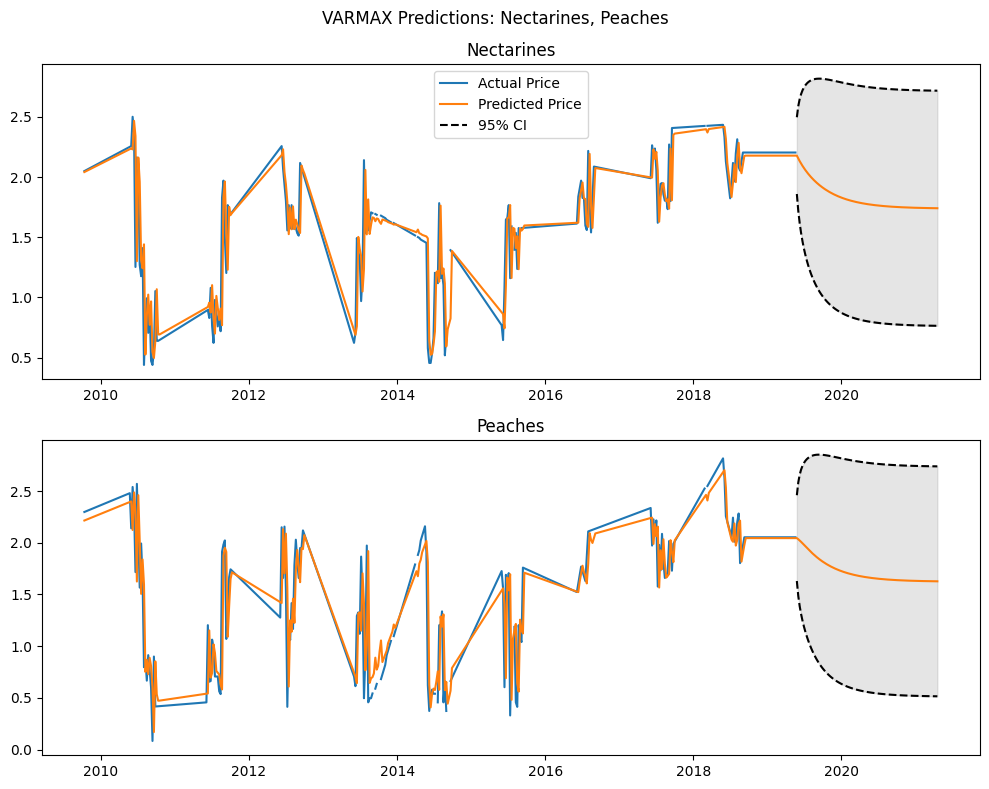

In [34]:
varmax_forecast_plot(df, ('Nectarines', 'Peaches'))

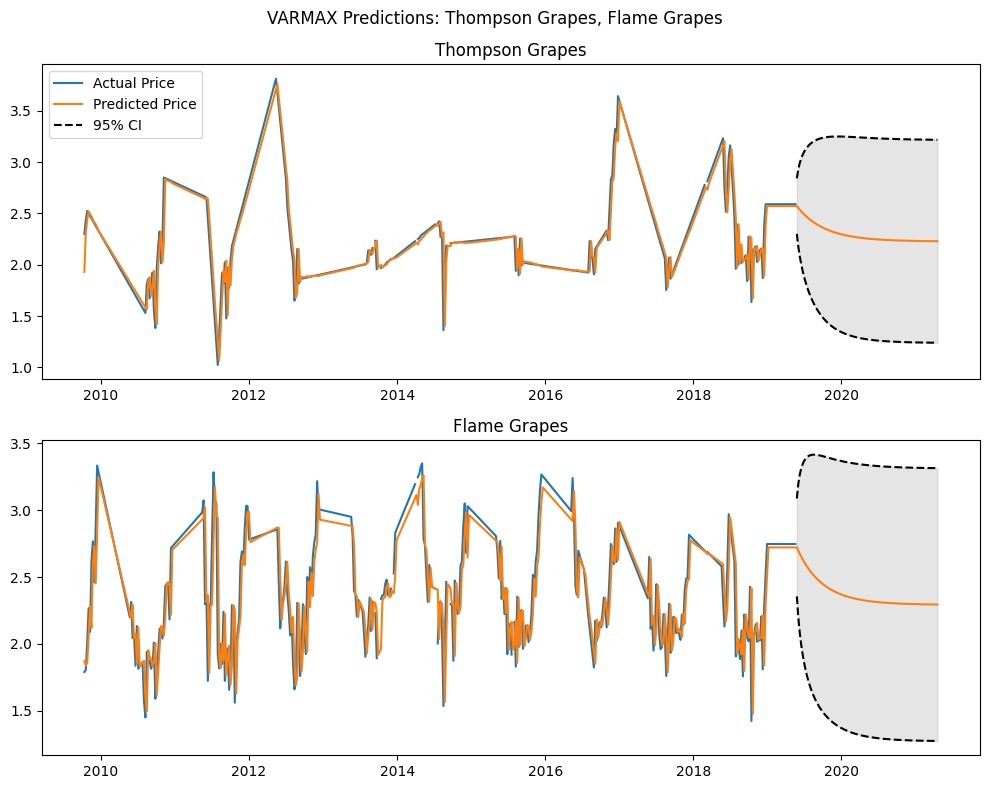

In [35]:
varmax_forecast_plot(df, ('Thompson Grapes', 'Flame Grapes'))

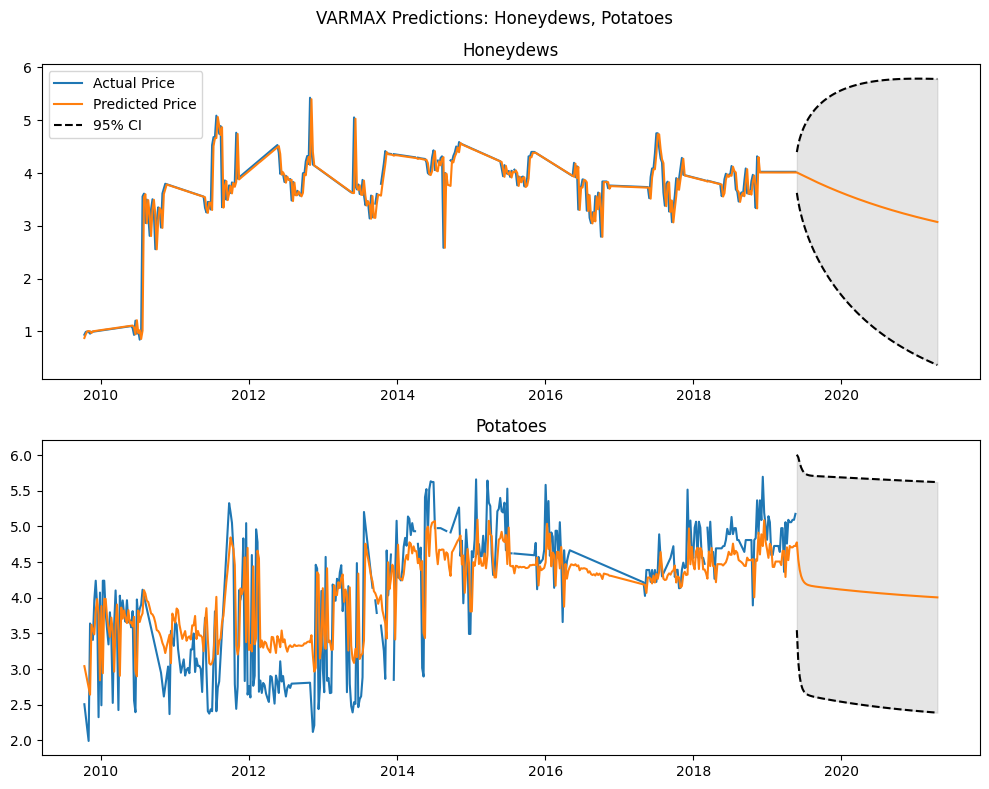

In [36]:
varmax_forecast_plot(df, ('Honeydews', 'Potatoes'))

In [ ]:
# plot both varma and arma predicted into future
def varma_arm_plot_forecast(df, fruits, n_steps=100, start_offset=4*52):
    # subset data
    data = df[list(fruits)].copy()

    # handle datetime index
    data.index = pd.to_datetime(data.index)
    data = data.asfreq("W-SUN")

    # future dates
    future_dates = pd.date_range(
        start=data.index[-1] + pd.Timedelta(weeks=1),
        periods=n_steps,
        freq="W-SUN"
    )

    # fit VARMAX
    var_model = VARMAX(data).fit(disp=False)
    var_pred = var_model.predict(start=data.index[0], end=future_dates[-1])

    # confidence intervals
    forecast_obj = var_model.get_forecast(steps=n_steps)
    all_CI = forecast_obj.conf_int(alpha=0.05)

    # plotting
    fig, axs = plt.subplots(len(fruits), 1, figsize=(10, 4 * len(fruits)))

    # if only one fruit, axs is not iterable
    if len(fruits) == 1:
        axs = [axs]

    for i, fruit in enumerate(fruits):
        # arm model for each fruit
        p, q = 1, 1
        arm_model = ARIMA(data[fruit], order=(p, 0, q), trend='c').fit()
        arm_pred = arm_model.predict(start=data.index[0], end=future_dates[-1])

        ax = axs[i]

        # actual + predicted
        ax.plot(data.iloc[start_offset:][fruit], label='Actual Price')
        ax.plot(var_pred.iloc[start_offset:][fruit], label='VARMA Predicted Price')
        ax.plot(arm_pred.iloc[start_offset:], label='AIRMA Predicted Price')


        ax.set_title(fruit)

        if i == 0:  # only plot legend once
            ax.legend()

    plt.suptitle(f'VARMAX Predictions: {", ".join(fruits)}')
    plt.tight_layout()
    plt.show()

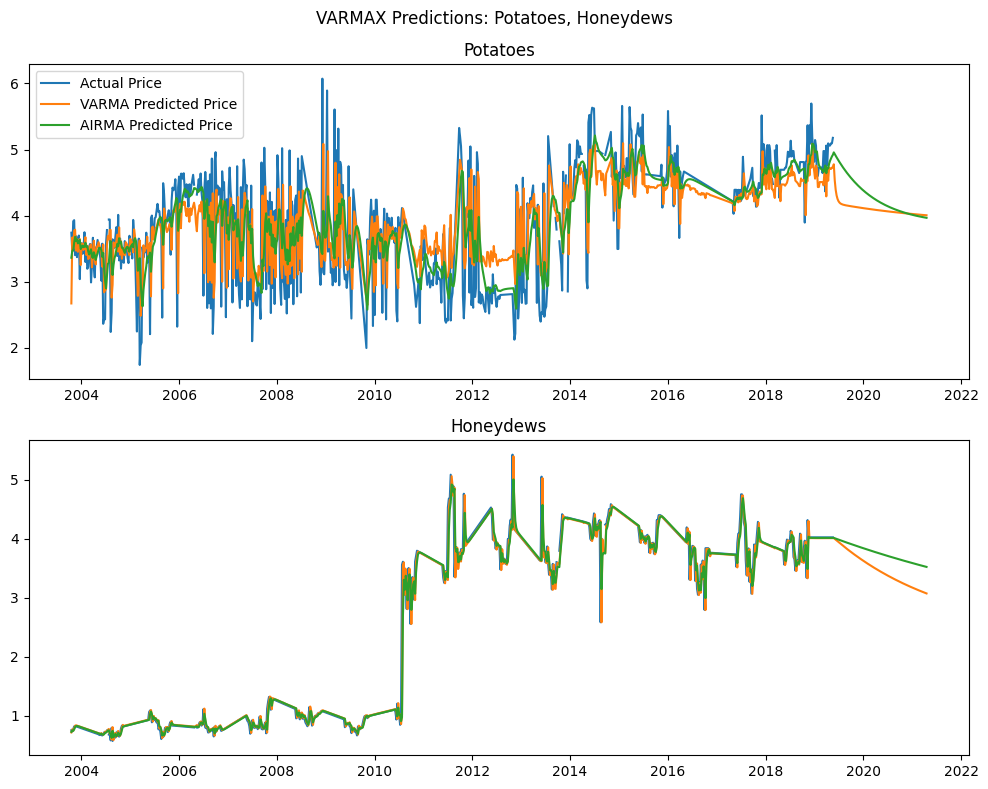

In [ ]:
varma_arm_plot_forecast(df, ('Potatoes', 'Honeydews'))

In [ ]:
# plot both varma and arm into test set
def varma_arm_plot_test(df, fruits, n_steps=100, start_offset=4*52):
    # subset data
    data = df[list(fruits)].copy()

    # handle datetime index
    data.index = pd.to_datetime(data.index)
    data = data.asfreq("W-SUN")

    # split into train/test
    train = data.iloc[:-n_steps]
    test = data.iloc[-n_steps:]

    # fit VARMAX on training set only
    var_model = VARMAX(train).fit(disp=False)
    var_forecast = var_model.forecast(steps=n_steps)


    # plotting
    fig, axs = plt.subplots(len(fruits), 1, figsize=(10, 4 * len(fruits)))

    # if only one fruit, axs is not iterable
    if len(fruits) == 1:
        axs = [axs]

    for i, fruit in enumerate(fruits):
        # fit ARMA/ARIMA on training set only
        p, q = 2, 1
        arm_model = ARIMA(train[fruit], order=(p, 0, q), trend='c').fit()
        arm_forecast = arm_model.forecast(steps=n_steps)

        ax = axs[i]

        # plot training truth
        ax.plot(train.iloc[start_offset:][fruit], label='Training Truth')

        # plot test truth
        ax.plot(test[fruit], label='Test Truth', linewidth=2)

        # plot forecasts
        ax.plot(var_forecast[fruit], label='VARMA Forecast')
        ax.plot(arm_forecast, label='ARMA Forecast')

        # vertical line where forecast begins
        ax.axvline(test.index[0], linestyle='--', color='gray')

        ax.set_title(fruit)

        if i == 0:
            ax.legend()

    plt.suptitle(f'VARMAX vs ARMA Forecasts: {", ".join(fruits)}')
    plt.tight_layout()
    plt.show()

/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


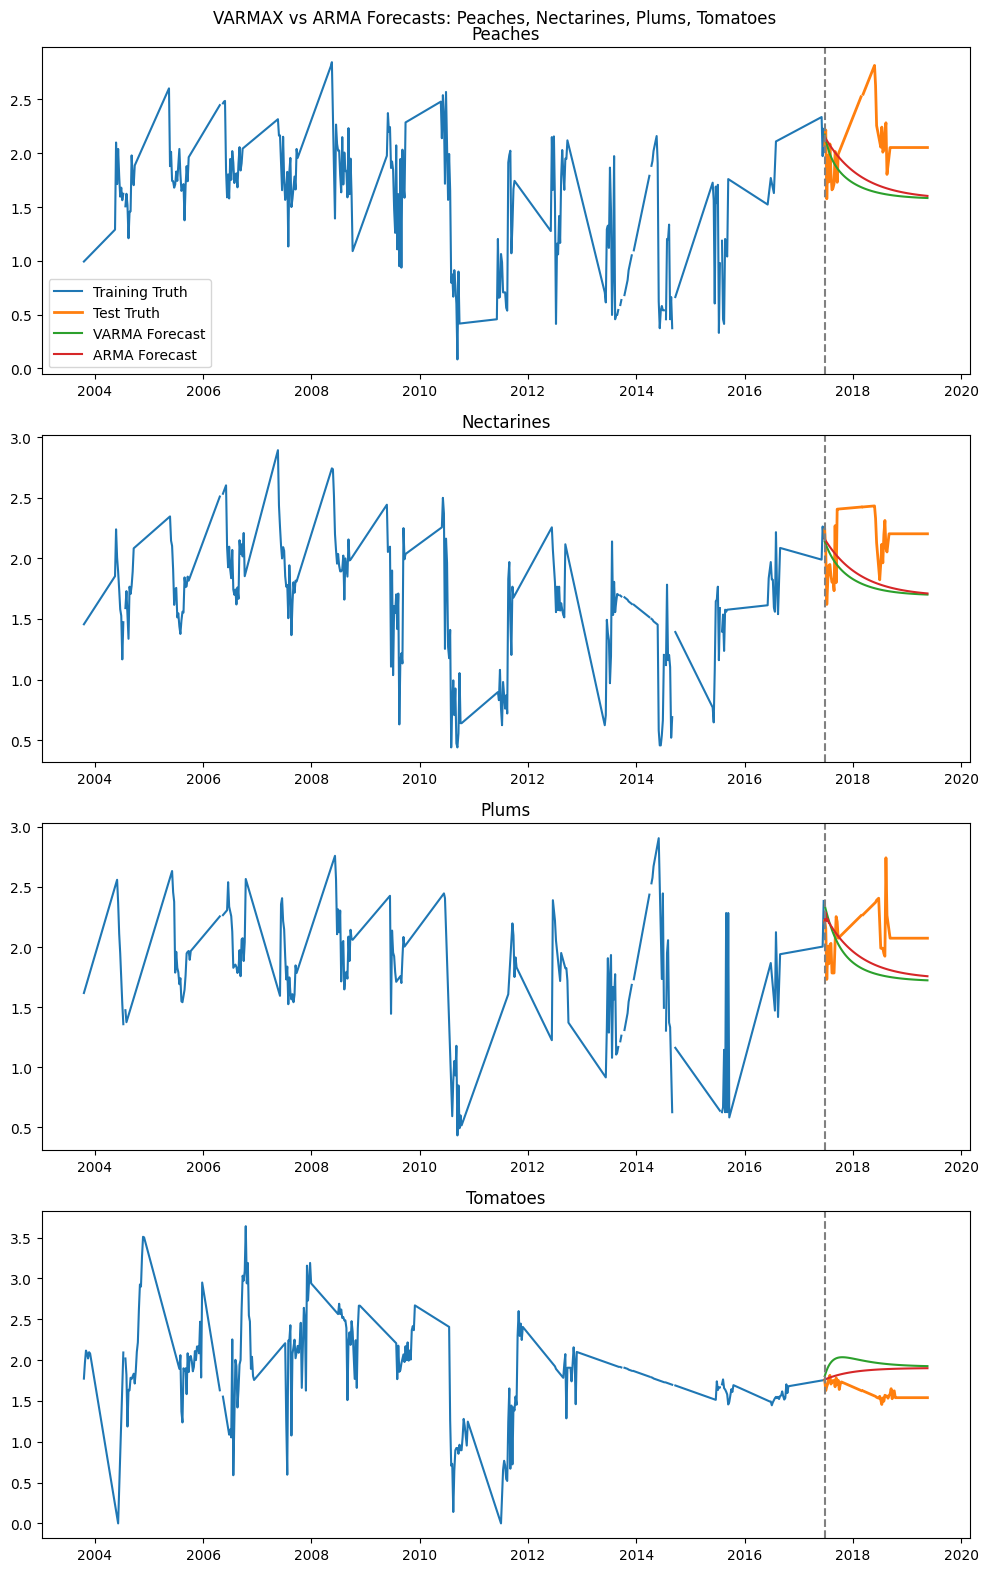

In [ ]:
varma_arm_plot_test(df, ('Peaches', 'Nectarines'))
varma_arm_plot_test(df, ('Peaches', 'Honeydews'))

In [62]:
def varma_arm_plot1(df, fruits, n_steps=100, start_offset=4*52):
    # just plot first fruit given (but varma trained on all given)

    # subset data
    data = df[list(fruits)].copy()

    # handle datetime index
    data.index = pd.to_datetime(data.index)
    data = data.asfreq("W-SUN")

    # split into train/test
    train = data.iloc[:-n_steps]
    test = data.iloc[-n_steps:]

    # fit VARMAX on training set only
    var_model = VARMAX(train).fit(disp=False)
    var_forecast = var_model.forecast(steps=n_steps)

    # fit ARMA/ARIMA on training set only
    fruit = fruits[0]
    p, q = 2, 1
    arm_model = ARIMA(train[fruit], order=(p, 0, q), trend='c').fit()
    arm_forecast = arm_model.forecast(steps=n_steps)

    # plot training truth
    plt.plot(train.iloc[start_offset:][fruit], label='Training Truth')

    # plot test truth
    plt.plot(test[fruit], label='Test Truth', linewidth=2)

    # plot forecasts
    plt.plot(var_forecast[fruit], label='VARMA Forecast')
    plt.plot(arm_forecast, label='ARMA Forecast')

    # vertical line where forecast begins
    plt.axvline(test.index[0], linestyle='--', color='gray')

    plt.title(fruit)

    plt.show()

/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


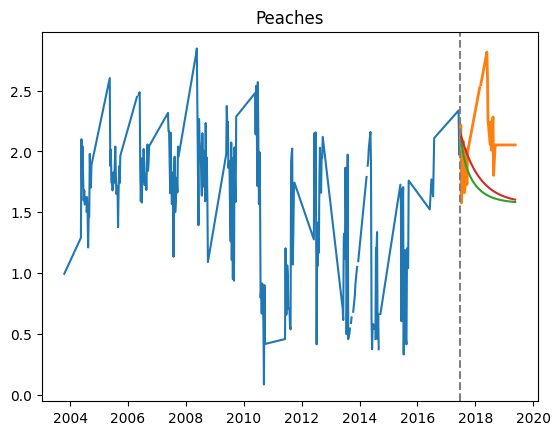

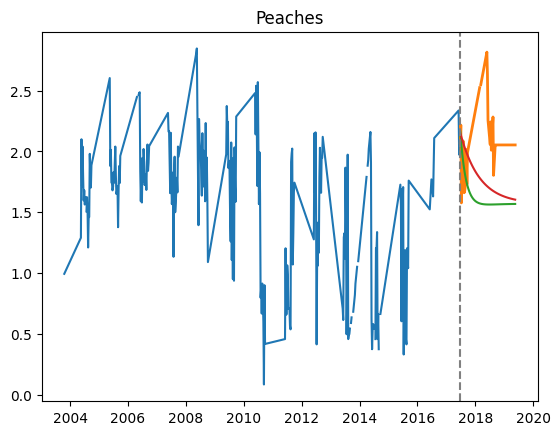

In [63]:
varma_arm_plot1(df, ('Peaches', 'Nectarines', 'Plums', 'Tomatoes'))
varma_arm_plot1(df, ('Peaches', 'Romaine Lettuce'))

In [78]:
# identify which fruit benefits most from VARMA

def best_partner_for_fruit(df, target_fruit="Strawberries", n_steps=20, var_order=(1, 0), arma_order=(1, 0, 1)):
    # handle dates and indices
    data = df.copy()
    data.index = pd.to_datetime(data.index)
    data = data.asfreq("W-SUN")
    data = data.select_dtypes(include="number")

    # spilt data
    train = data[[target_fruit]].iloc[:-n_steps]
    test = data[[target_fruit]].iloc[-n_steps:]

    # arma model to find mse and compare to baseline
    arma_model = ARIMA(train[target_fruit], order=arma_order, trend='c').fit()
    arma_forecast = arma_model.forecast(steps=n_steps)
    y_true = test[target_fruit]
    arma_mse = np.mean((y_true - arma_forecast) ** 2)

    results = []

    for other_fruit in data.columns:    # iterate through fruits on which to VARMA
        if other_fruit == target_fruit: # don't compare to itself
            continue

        pair_data = data[[target_fruit, other_fruit]]
        train = pair_data.iloc[:-n_steps]
        test = pair_data.iloc[-n_steps:]

        # build varmax model with target fruit ad other fruit
        var_model = VARMAX(train[[target_fruit, other_fruit]], order=var_order).fit(disp=False)
        var_forecast = var_model.forecast(steps=n_steps)

        var_mse = np.mean((y_true - var_forecast[target_fruit]) ** 2)   # get mse 

        improvement = arma_mse - var_mse
        pct_improvement = 100 * improvement / arma_mse if arma_mse != 0 else np.nan

        # print results for each fruit 
        results.append({
            "partner_fruit": other_fruit,
            "VARMAX_MSE": float(var_mse),
            "ARMA_MSE": float(arma_mse),
            "improvement": float(improvement),
            "pct_improvement": float(pct_improvement),
        })


    ordered_results = sorted(results, key=lambda r: r["VARMAX_MSE"])    # sort by VARMAX MSE

    best_result = ordered_results[0]
    return [(ordered_result['partner_fruit'], ordered_result["VARMAX_MSE"]) for ordered_result in ordered_results]

In [79]:
best_partner_for_fruit(df,'Strawberries')

/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[('Flame Grapes', 0.20081033877810386),
 ('Celery', 0.2431747700392517),
 ('Plums', 0.25763524173454505),
 ('Avocados', 0.2667269557269316),
 ('Iceberg Lettuce', 0.27241804348365184),
 ('Asparagus', 0.2818717597111957),
 ('Romaine Lettuce', 0.2820048970151933),
 ('Peaches', 0.28661057090072467),
 ('Green Leaf Lettuce', 0.28906196522890515),
 ('Tomatoes', 0.2997827709762221),
 ('Carrots', 0.30132135614681577),
 ('Broccoli Bunches', 0.30665898594756913),
 ('Potatoes', 0.3081136696340535),
 ('Red Leaf Lettuce', 0.3082827585782141),
 ('Nectarines', 0.3089888938163613),
 ('Broccoli Crowns', 0.3135232606947716),
 ('Thompson Grapes', 0.3168010634960293),
 ('Cauliflower', 0.3201424657024511),
 ('Honeydews', 0.324656396790002),
 ('Cantaloupe', 0.32515929708955066),
 ('Oranges', 0.3286484235910585)]

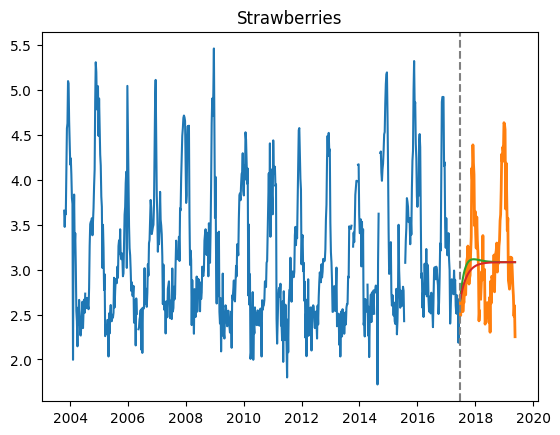

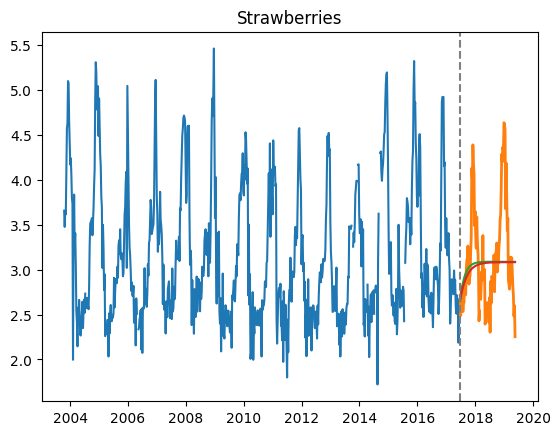

In [77]:
varma_arm_plot1(df, ('Strawberries', 'Flame Grapes'))
varma_arm_plot1(df, ('Strawberries', 'Oranges'))

In [80]:
best_partner_for_fruit(df,'Peaches')

/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


[('Nectarines', 0.0240870644419457),
 ('Strawberries', 0.0342087758994087),
 ('Thompson Grapes', 0.04058306345114869),
 ('Plums', 0.042980487761005756),
 ('Flame Grapes', 0.04493240166040367),
 ('Green Leaf Lettuce', 0.05268580236653986),
 ('Potatoes', 0.057006814766133604),
 ('Broccoli Crowns', 0.057518329012650984),
 ('Asparagus', 0.05988551123356387),
 ('Carrots', 0.06003101938245166),
 ('Red Leaf Lettuce', 0.060736113493516306),
 ('Avocados', 0.0608121321753148),
 ('Celery', 0.06222430997016663),
 ('Broccoli Bunches', 0.06419694795278047),
 ('Oranges', 0.0697993712924498),
 ('Cauliflower', 0.0786620792246662),
 ('Romaine Lettuce', 0.08142190498437431),
 ('Cantaloupe', 0.08812476086836953),
 ('Iceberg Lettuce', 0.08878519050240603),
 ('Tomatoes', 0.09051059663905504),
 ('Honeydews', 0.10104301738516504)]

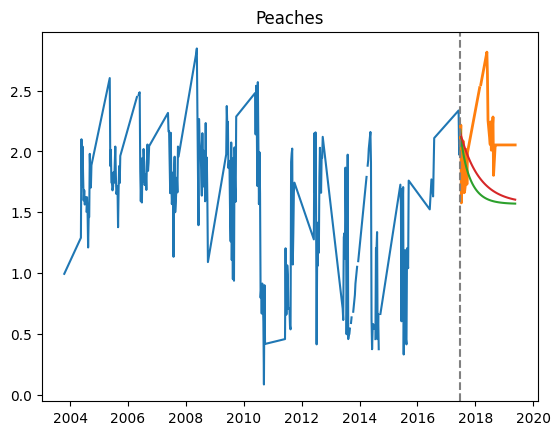

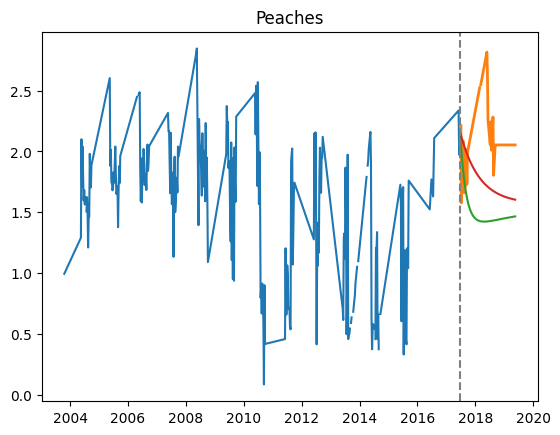

In [83]:
varma_arm_plot1(df, ('Peaches', 'Nectarines'))
varma_arm_plot1(df, ('Peaches', 'Honeydews'))

In [90]:
print(f"Asparagus: {best_partner_for_fruit(df,'Asparagus')}")
print(f"Thompson Grapes: {best_partner_for_fruit(df,'Thompson Grapes')}")
print(f"Peaches: {best_partner_for_fruit(df,'Peaches')}")
print(f"Avocados: {best_partner_for_fruit(df,'Avocados')}")
print(f"Honeydews: {best_partner_for_fruit(df,'Honeydews')}")

Asparagus: [('Strawberries', 0.11561987265580768), ('Iceberg Lettuce', 0.18566524192902084), ('Thompson Grapes', 0.18886695374240783), ('Green Leaf Lettuce', 0.18908688546793795), ('Red Leaf Lettuce', 0.19320579979849148), ('Broccoli Crowns', 0.19541975629971003), ('Potatoes', 0.19567403957512153), ('Celery', 0.1975367705952002), ('Romaine Lettuce', 0.197689870234643), ('Tomatoes', 0.19795159599821327), ('Broccoli Bunches', 0.19872150541096859), ('Avocados', 0.20180680153014308), ('Nectarines', 0.2044968897337116), ('Peaches', 0.20688875120116612), ('Cantaloupe', 0.21029236006509922), ('Plums', 0.21508294567759392), ('Carrots', 0.2152115238035849), ('Flame Grapes', 0.21722549724475862), ('Cauliflower', 0.22044381223516601), ('Honeydews', 0.2398370750567002), ('Oranges', 0.2427853945017755)]


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Thompson Grapes: [('Strawberries', 0.0013091608020227672), ('Romaine Lettuce', 0.007689329885248629), ('Cantaloupe', 0.008177500664648424), ('Nectarines', 0.009905060677508215), ('Green Leaf Lettuce', 0.010979347306959144), ('Iceberg Lettuce', 0.01199903214989216), ('Honeydews', 0.012642526132117502), ('Cauliflower', 0.012913403749981076), ('Potatoes', 0.01315318263996797), ('Red Leaf Lettuce', 0.014732370685147999), ('Carrots', 0.014949443408829546), ('Broccoli Crowns', 0.015624696600461879), ('Peaches', 0.01577310342325534), ('Oranges', 0.016534137513365), ('Asparagus', 0.016633165581663393), ('Broccoli Bunches', 0.017515127978329728), ('Celery', 0.01803062170689497), ('Plums', 0.018045996258985925), ('Avocados', 0.01874287340471526), ('Tomatoes', 0.020612924326700765), ('Flame Grapes', 0.026228961606961226)]


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Peaches: [('Nectarines', 0.0240870644419457), ('Strawberries', 0.0342087758994087), ('Thompson Grapes', 0.04058306345114869), ('Plums', 0.042980487761005756), ('Flame Grapes', 0.04493240166040367), ('Green Leaf Lettuce', 0.05268580236653986), ('Potatoes', 0.057006814766133604), ('Broccoli Crowns', 0.057518329012650984), ('Asparagus', 0.05988551123356387), ('Carrots', 0.06003101938245166), ('Red Leaf Lettuce', 0.060736113493516306), ('Avocados', 0.0608121321753148), ('Celery', 0.06222430997016663), ('Broccoli Bunches', 0.06419694795278047), ('Oranges', 0.0697993712924498), ('Cauliflower', 0.0786620792246662), ('Romaine Lettuce', 0.08142190498437431), ('Cantaloupe', 0.08812476086836953), ('Iceberg Lettuce', 0.08878519050240603), ('Tomatoes', 0.09051059663905504), ('Honeydews', 0.10104301738516504)]


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Avocados: [('Strawberries', 0.023145926907960697), ('Romaine Lettuce', 0.026481338376347724), ('Honeydews', 0.026534378211382964), ('Iceberg Lettuce', 0.02656396266226202), ('Flame Grapes', 0.026588325231105964), ('Cantaloupe', 0.02671557990538012), ('Cauliflower', 0.0272898310924758), ('Oranges', 0.02731498174109458), ('Green Leaf Lettuce', 0.027397263571244453), ('Peaches', 0.02799508978456642), ('Thompson Grapes', 0.02813715899956164), ('Nectarines', 0.028389661255710484), ('Broccoli Bunches', 0.028590983514985503), ('Broccoli Crowns', 0.02861351952783083), ('Carrots', 0.028682093317581515), ('Potatoes', 0.029082575890196666), ('Red Leaf Lettuce', 0.029683613180947838), ('Asparagus', 0.029803906879899582), ('Celery', 0.029925167780975908), ('Tomatoes', 0.03250574259195952), ('Plums', 0.03343476134499202)]
Honeydews: [('Oranges', 0.003912699368381965), ('Romaine Lettuce', 0.012110837841948403), ('Avocados', 0.019414468496556564), ('Cantaloupe', 0.02026016539657401), ('Green Leaf Lett

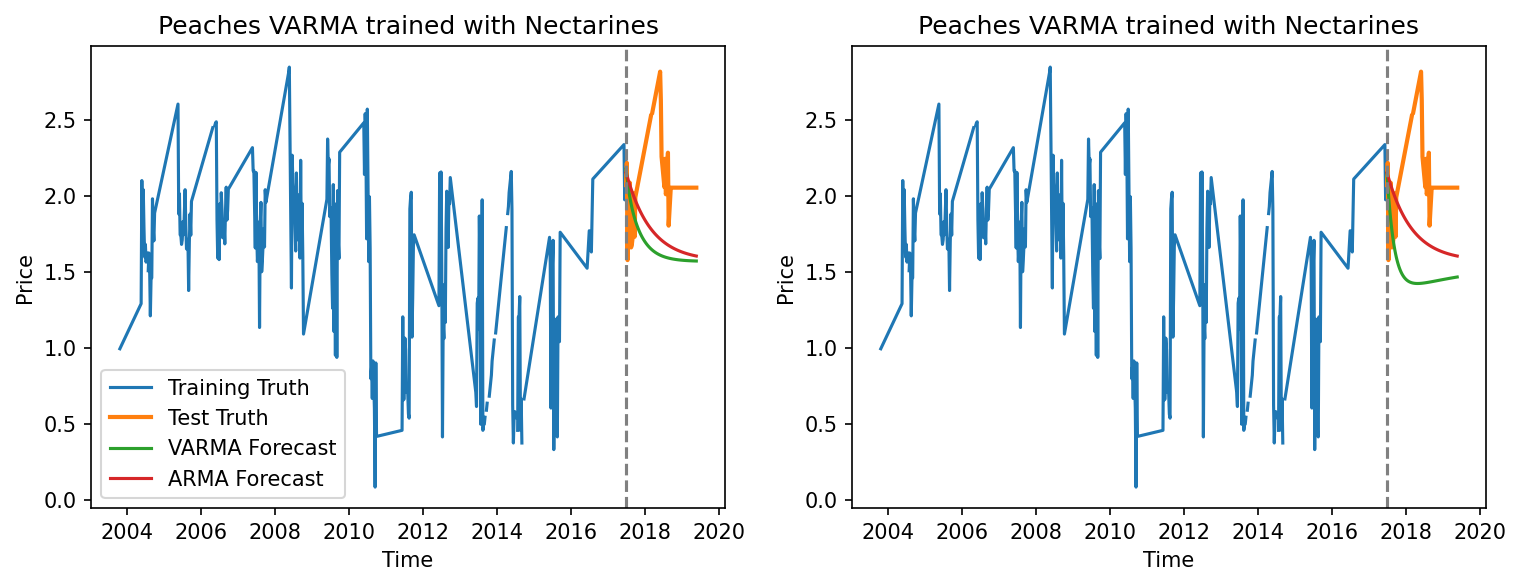

In [101]:
fruits = ('Peaches', 'Nectarines')
n_steps = 100
start_offset=4*52
fig, axs = plt.subplots(1, 2, figsize=(12, 4), dpi=150)


# just plot first fruit given (but varma trained on all given)
# subset data
data = df[list(fruits)].copy()

# handle datetime index
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")

# split into train/test
train = data.iloc[:-n_steps]
test = data.iloc[-n_steps:]

# fit VARMAX on training set only
var_model = VARMAX(train).fit(disp=False)
var_forecast = var_model.forecast(steps=n_steps)

# fit ARMA/ARIMA on training set only
fruit = fruits[0]
p, q = 2, 1
arm_model = ARIMA(train[fruit], order=(p, 0, q), trend='c').fit()
arm_forecast = arm_model.forecast(steps=n_steps)

# plot training truth
axs[0].plot(train.iloc[start_offset:][fruit], label='Training Truth')

# plot test truth
axs[0].plot(test[fruit], label='Test Truth', linewidth=2)

# plot forecasts
axs[0].plot(var_forecast[fruit], label='VARMA Forecast')
axs[0].plot(arm_forecast, label='ARMA Forecast')

# vertical line where forecast begins
axs[0].axvline(test.index[0], linestyle='--', color='gray')

axs[0].set_title('Peaches VARMA trained with Nectarines')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Price')
axs[0].legend()




fruits = ('Peaches', 'Honeydews')
# just plot first fruit given (but varma trained on all given)

# subset data
data = df[list(fruits)].copy()

# handle datetime index
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")

# split into train/test
train = data.iloc[:-n_steps]
test = data.iloc[-n_steps:]

# fit VARMAX on training set only
var_model = VARMAX(train).fit(disp=False)
var_forecast = var_model.forecast(steps=n_steps)

# fit ARMA/ARIMA on training set only
fruit = fruits[0]
p, q = 2, 1
arm_model = ARIMA(train[fruit], order=(p, 0, q), trend='c').fit()
arm_forecast = arm_model.forecast(steps=n_steps)

# plot training truth
axs[1].plot(train.iloc[start_offset:][fruit], label='Training Truth')

# plot test truth
axs[1].plot(test[fruit], label='Test Truth', linewidth=2)

# plot forecasts
axs[1].plot(var_forecast[fruit], label='VARMA Forecast')
axs[1].plot(arm_forecast, label='ARMA Forecast')

# vertical line where forecast begins
axs[1].axvline(test.index[0], linestyle='--', color='gray')

axs[1].set_title('Peaches VARMA trained with Nectarines')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Price')

plt.show()

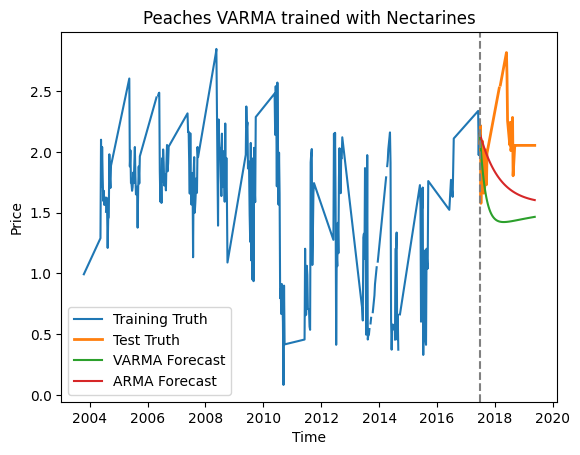

In [93]:
fruits = ('Peaches', 'Honeydews')
n_steps = 100
start_offset=4*52
# just plot first fruit given (but varma trained on all given)

# subset data
data = df[list(fruits)].copy()

# handle datetime index
data.index = pd.to_datetime(data.index)
data = data.asfreq("W-SUN")

# split into train/test
train = data.iloc[:-n_steps]
test = data.iloc[-n_steps:]

# fit VARMAX on training set only
var_model = VARMAX(train).fit(disp=False)
var_forecast = var_model.forecast(steps=n_steps)

# fit ARMA/ARIMA on training set only
fruit = fruits[0]
p, q = 2, 1
arm_model = ARIMA(train[fruit], order=(p, 0, q), trend='c').fit()
arm_forecast = arm_model.forecast(steps=n_steps)

# plot training truth
plt.plot(train.iloc[start_offset:][fruit], label='Training Truth')

# plot test truth
plt.plot(test[fruit], label='Test Truth', linewidth=2)

# plot forecasts
plt.plot(var_forecast[fruit], label='VARMA Forecast')
plt.plot(arm_forecast, label='ARMA Forecast')

# vertical line where forecast begins
plt.axvline(test.index[0], linestyle='--', color='gray')

plt.title('Peaches VARMA trained with Nectarines')
plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()
plt.show()